In [31]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
names = [n.lower().strip() for n in pd.read_csv("Popular Baby Names.csv")["Child's First Name"].unique() if len(n.split()) == 1 and "'" not in n]
len(names)

3298

In [3]:
ctoi = {'.': 0}

for i in range(97, 123):
    ctoi[chr(i)] = i-96

itoc = {v:k for k,v in ctoi.items()}
itoc

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [135]:
xs = []
ys = []

for w in names[:1]:
    buffer = [0]*3
    for c in w + ".":
        txs = [itoc[x] for x in buffer]
        print(" ".join(txs), "->", c)
        xs.append(buffer[:])
        ys.append(ctoi[c])
        buffer.pop(0)
        buffer.append(ctoi[c])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. . . -> c
. . c -> h
. c h -> l
c h l -> o
h l o -> e
l o e -> .


In [136]:
xs.shape, ys.shape

(torch.Size([6, 3]), torch.Size([6]))

In [137]:
W = torch.randn((27, 3), requires_grad=True)
W

tensor([[-0.1221, -0.8434, -0.4893],
        [ 0.1492,  0.8186, -0.4832],
        [ 1.2586, -0.2219,  1.2441],
        [ 0.3903,  0.9362, -0.5684],
        [-0.4681,  1.1722, -0.3527],
        [ 1.1612, -0.7141, -0.5686],
        [-0.4463, -1.2072,  0.1100],
        [ 0.5039,  1.5487, -0.5885],
        [-0.5406,  0.5782,  1.8427],
        [-0.6261,  1.6851,  2.2477],
        [-0.2790, -0.6177,  0.4975],
        [ 0.9592, -1.4004,  0.1930],
        [ 1.6472, -1.3037, -0.5798],
        [-0.0652, -1.1727,  0.9730],
        [-1.2117, -1.1021,  0.0761],
        [ 0.6734,  0.7010,  0.5769],
        [-0.0052,  2.5582, -0.5329],
        [ 1.0354, -2.5762,  2.1302],
        [-1.6294,  1.2951,  2.2840],
        [ 0.7009,  0.9164,  0.2182],
        [ 0.1884, -0.5821, -0.0552],
        [-2.1325,  0.5440,  0.2459],
        [-1.4286,  1.1013, -0.8038],
        [-0.5154,  0.7390,  0.0646],
        [-1.0054,  0.5494, -0.1624],
        [-0.5183, -0.8511, -1.5874],
        [-0.8750,  0.6959, -0.3844]], 

In [138]:
torch.functional.F.one_hot(torch.tensor([2]), num_classes=27).float() @ W

tensor([[ 1.2586, -0.2219,  1.2441]], grad_fn=<MmBackward0>)

In [139]:
W[2]

tensor([ 1.2586, -0.2219,  1.2441], grad_fn=<SelectBackward0>)

In [140]:
L1 = W[xs]
L1.shape

torch.Size([6, 3, 3])

In [141]:
W1 = torch.randn((9, 100), requires_grad=True)
b1 = torch.randn((100,), requires_grad=True)
W1.shape, b1.shape

(torch.Size([9, 100]), torch.Size([100]))

In [142]:
L2 = L1.view((6,9)) @ W1 + b1
L2 = L2.tanh()
L2.shape

torch.Size([6, 100])

In [143]:
W2 = torch.randn((100, 27), requires_grad=True)
b2 = torch.randn((27,), requires_grad=True)

In [144]:
logits = L2 @ W2 + b2
loss = torch.nn.functional.cross_entropy(logits, ys)
loss

tensor(18.5892, grad_fn=<NllLossBackward0>)

In [19]:
xs = []
ys = []
emb_dim = 3
wt = 3
epochs = []
results = []
epoch = 0

for w in names:
    buffer = [0]*wt
    for c in w + ".":
        txs = [itoc[x] for x in buffer]
        xs.append(buffer[:])
        ys.append(ctoi[c])
        buffer.pop(0)
        buffer.append(ctoi[c])

xs = torch.tensor(xs)
ys = torch.tensor(ys)
xs.shape, ys.shape

(torch.Size([22421, 3]), torch.Size([22421]))

In [20]:
n_samples = xs.shape[0]
n1 = int(0.8 * n_samples)
n2 = int(0.9 * n_samples)

indices = torch.randperm(n_samples)

xtr, xval, xtest = xs[indices[:n1]], xs[indices[n1:n2]], xs[indices[n2:]]
ytr, yval, ytest = ys[indices[:n1]], ys[indices[n1:n2]], ys[indices[n2:]]

print(xtr.shape, ytr.shape)
print(xval.shape, yval.shape)
print(xtest.shape, ytest.shape)

torch.Size([17936, 3]) torch.Size([17936])
torch.Size([2242, 3]) torch.Size([2242])
torch.Size([2243, 3]) torch.Size([2243])


In [21]:
emb = torch.randn((27, emb_dim), requires_grad=True)
W2 = torch.randn((emb_dim * wt, 100), requires_grad=True)
b2 = torch.randn((100,), requires_grad=True)
W3 = torch.randn((100, 27), requires_grad=True)
b3 = torch.randn((27,), requires_grad=True)
parameters = [emb, W2, b2, W3, b3]
sum([p.nelement() for p in parameters])

3808

In [60]:
for _ in range(100):
    epoch += 1
    # forward pass
    # input layer
    L1 = emb[xtr]
    # hidden layer 1
    L2 = L1.view((xtr.shape[0], emb_dim * wt)) @ W2 + b2
    L2 = L2.tanh()
    # out layer
    logits = L2 @ W3 + b3
    # loss
    loss = torch.nn.functional.cross_entropy(logits, ytr)
    # zero grad
    for p in parameters:
        p.grad = None
    
    # backward pass
    loss.backward()
    
    # gradient update
    for p in parameters:
        p.data += -0.01 * p.grad

    epochs.append(epoch)
    results.append(loss.item())
    print(f"{epoch=}, {loss=}")

epoch=3201, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3202, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3203, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3204, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3205, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3206, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3207, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3208, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3209, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3210, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3211, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3212, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3213, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3214, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3215, loss=tensor(2.4241, grad_fn=<NllLossBackward0>)
epoch=3216, loss=tensor(2.4240, grad_fn=<NllLossBackward0>)
epoch=3217, loss=tensor(2.4240, grad_fn=

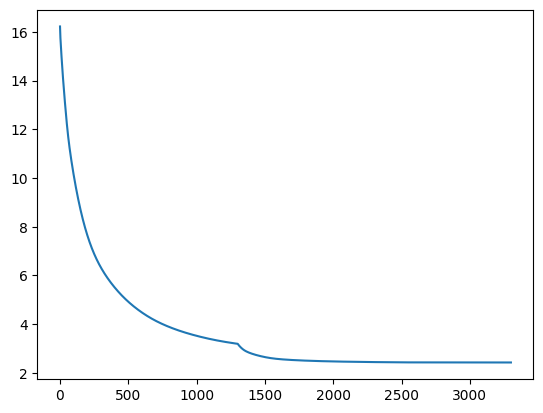

In [61]:
plt.plot(epochs, results)

In [62]:
L1 = emb[xval]
L2 = L1.view((xval.shape[0], emb_dim * wt)) @ W2 + b2
L2 = L2.tanh()
logits = L2 @ W3 + b3
loss_val = torch.nn.functional.cross_entropy(logits, yval)
loss_val

tensor(2.4700, grad_fn=<NllLossBackward0>)

In [63]:
L1 = emb[xtest]
L2 = L1.view((xtest.shape[0], emb_dim * wt)) @ W2 + b2
L2 = L2.tanh()
logits = L2 @ W3 + b3
loss_val = torch.nn.functional.cross_entropy(logits, ytest)
loss_val

tensor(2.4547, grad_fn=<NllLossBackward0>)